# High-Order Kuramoto Network for Multiple Sequences; implementation of dense associative memory (Krotov)

This notebook tests d=3 high-order Kuramoto-type oscillator network 

$$\dot{\theta}_i
=
-\sin\theta_i
\sum_{\mu=1}^{P}
\xi_i^{\mu+1}
\left(
\frac{1}{N-1}
\sum_{j\neq i}
\xi_j^\mu
\cos\theta_j
\right)^d$$


For multiple sequences:

$$\dot{\theta}_i
=
-\sin\theta_i
\sum_{a=1}^{K}
\sum_{\mu=1}^{P_a}
\xi_i^{a,\mu+1}
\left(
\frac{1}{N-1}
\sum_{j\neq i}
\xi_j^{a,\mu}
\cos\theta_j
\right)^d$$

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from numba import njit

np.set_printoptions(precision=3, suppress=True)


## 1. Model

For memory $\mu$, define the overlap of state with some pattern as

$$m_i^\mu(\boldsymbol{\theta})
=
\frac{1}{N-1}
\sum_{j\neq i}
\xi_j^\mu
\cos\theta_j$$




In [2]:
MEMORY_NAMES = ["A", "B", "C", "D", "E"]
A, B, C, D, E = range(5)

DEFAULTS = dict(
    N=40,  # number of units / neurons in the associative memory network
    dt=0.02,  # integration timestep for the dynamical evolution
    T=55.0,  # total simulation time
    frequency_std=0.03,  # heterogeneity in intrinsic frequencies, adding disorder to retrieval dynamics
    phase_noise=0.01,  # stochastic phase perturbations during evolution (SDE mode only)
    seed=10,  # random seed for reproducibility
    d=3,  # order (polynomial degree) of the high-order Kuramoto / dense associative memory coupling
    corruption_rate=0.2,  # fraction of neurons flipped in the cue used to initialize theta
)


In [3]:
def corrupt_pattern(phase_pattern, corruption_rate=DEFAULTS["corruption_rate"], seed=DEFAULTS["seed"]):
    """Return a copy of a phase pattern with a random subset of neurons flipped (0 <-> pi)."""
    rng = np.random.default_rng(seed)
    phase_pattern = phase_pattern.copy()
    if corruption_rate <= 0:
        return phase_pattern

    num_flips = int(corruption_rate * phase_pattern.shape[0])
    flip_idx = rng.choice(phase_pattern.shape[0], size=num_flips, replace=False)
    phase_pattern[flip_idx] = np.pi - phase_pattern[flip_idx]
    return phase_pattern


def make_memories(N=40, seed=DEFAULTS["seed"]):
    """Generate five random binary phase memories, the sequence xi^1 -> xi^2 -> ... -> xi^5.

    `phases` holds the target angles (0 or pi) and is only used to build initial/cue
    conditions. `xi` is the spin representation (+-1) that enters the overlap and the
    Kuramoto dynamics themselves, so the stored patterns are never accidentally corrupted.
    """
    rng = np.random.default_rng(seed)
    phases = rng.choice([0.0, np.pi], size=(5, N))
    xi = np.cos(phases)

    PATTERN_DICT = dict(zip(MEMORY_NAMES, xi))
    return phases, xi, PATTERN_DICT


def overlaps(theta, xi):
    """Global overlap m^mu(t) = (1/N) sum_i xi_i^mu cos(theta_i) for every stored pattern.

    This is the signed diagnostic overlap from the spec (not the leave-one-out term used
    inside the dynamics), so a negative value simply means the state is anti-aligned with
    that pattern rather than indicating a bug.
    """
    return xi @ np.cos(theta) / xi.shape[1]


## The ODE Dynamics (Deterministic Forward Euler)

In [4]:
def simulate_ode_euler(omega, phases, xi, d=DEFAULTS["d"], dt=DEFAULTS["dt"], T=DEFAULTS["T"],
                        corruption_rate=DEFAULTS["corruption_rate"], seed=DEFAULTS["seed"]):
    """
    Deterministic Forward Euler simulation for oscillator dynamics.

    theta is initialized at a corrupted copy of the zeroth pattern; the stored patterns
    `xi` used inside the dynamics are always the clean, uncorrupted memories.
    """
    num_steps = int(T / dt)
    theta_init = corrupt_pattern(phases[0], corruption_rate=corruption_rate, seed=seed)
    return _simulate_ode_euler_impl(theta_init, omega, xi, d, dt, num_steps)


@njit
def _simulate_ode_euler_impl(theta_init, omega, xi, d, dt, num_steps):
    N = theta_init.shape[0]
    P = xi.shape[0]  # number of stored patterns in the sequence (periodic: P+1 == 1)

    # Pre-allocate history array
    history = np.empty((num_steps + 1, N), dtype=np.float64)
    theta = theta_init.copy()
    history[0] = theta

    # Pre-allocate static memory buffers
    cos_theta = np.empty(N, dtype=np.float64)
    sin_theta = np.empty(N, dtype=np.float64)
    S = np.empty(P, dtype=np.float64)

    for step in range(num_steps):
        # Precompute trigonometric arrays
        for i in range(N):
            cos_theta[i] = np.cos(theta[i])
            sin_theta[i] = np.sin(theta[i])

        # Precompute pattern-wide sums (S^mu)
        for mu in range(P):
            temp_sum = 0.0
            for j in range(N):
                temp_sum += xi[mu, j] * cos_theta[j]
            S[mu] = temp_sum

        # Calculate derivatives and update states
        for i in range(N):
            V = 0.0
            for mu in range(P):
                inner_sum = S[mu] - xi[mu, i] * cos_theta[i]
                h = (inner_sum / (N - 1)) ** d
                V += xi[(mu + 1) % P, i] * h

            # Incorporate intrinsic frequency omega_i
            dtheta_i = omega[i] - sin_theta[i] * V

            # Deterministic update
            theta[i] = theta[i] + dt * dtheta_i

        history[step + 1] = theta.copy()


    return history

## The SDE Dynamics (Stochastic Euler-Maruyama)

In [5]:
def simulate_sde_maruyama(omega, phases, xi, d=DEFAULTS["d"], dt=DEFAULTS["dt"], T=DEFAULTS["T"],
                           phase_noise=DEFAULTS["phase_noise"], corruption_rate=DEFAULTS["corruption_rate"],
                           seed=DEFAULTS["seed"]):
    """
    Stochastic Euler-Maruyama simulation for oscillator dynamics with phase noise.
    """
    num_steps = int(T / dt)
    theta_init = corrupt_pattern(phases[0], corruption_rate=corruption_rate, seed=seed)
    return _simulate_sde_maruyama_impl(theta_init, omega, xi, d, dt, num_steps, phase_noise)


@njit
def _simulate_sde_maruyama_impl(theta_init, omega, xi, d, dt, num_steps, phase_noise):
    N = theta_init.shape[0]
    P = xi.shape[0]  # number of stored patterns in the sequence (periodic: P+1 == 1)

    # Pre-allocate history array
    history = np.empty((num_steps + 1, N), dtype=np.float64)
    theta = theta_init.copy()
    history[0] = theta

    # Pre-allocate static memory buffers
    cos_theta = np.empty(N, dtype=np.float64)
    sin_theta = np.empty(N, dtype=np.float64)
    S = np.empty(P, dtype=np.float64)

    # Scaling factor for the Wiener process noise
    noise_scale = phase_noise * np.sqrt(dt)

    for step in range(num_steps):
        # Precompute trigonometric arrays
        for i in range(N):
            cos_theta[i] = np.cos(theta[i])
            sin_theta[i] = np.sin(theta[i])

        # Precompute pattern-wide sums (S^mu)
        for mu in range(P):
            temp_sum = 0.0
            for j in range(N):
                temp_sum += xi[mu, j] * cos_theta[j]
            S[mu] = temp_sum

        # Calculate derivatives, add noise, and update states
        for i in range(N):
            V = 0.0
            for mu in range(P):
                inner_sum = S[mu] - xi[mu, i] * cos_theta[i]
                h = (inner_sum / (N - 1)) ** d
                V += xi[(mu + 1) % P, i] * h

            dtheta_i = omega[i] - sin_theta[i] * V

            # Stochastic update: Deterministic drift + Stochastic diffusion
            random_shock = np.random.randn()
            theta[i] = theta[i] + (dt * dtheta_i) + (noise_scale * random_shock)

        history[step + 1] = theta.copy()

    return history

In [6]:
def run_trial(config, mode="ode"):
    """
    Coordinates a single simulation trial: builds the stored sequence, corrupts a copy of
    the zeroth pattern to use as the initial condition, integrates the high-order Kuramoto
    dynamics, and tracks the overlap with every stored pattern over time.

    Parameters:
    -----------
    config : dict
        Dictionary containing network parameters (e.g., DEFAULTS).
    mode : str
        The simulation style to run: 'ode' or 'sde'.

    Returns:
    --------
    results : dict
        Contains 'time', 'theta_history', 'overlap_history', and 'corrupted_pattern_overlap'.
    """

    # 1. Extract parameters from config
    N = config['N']
    dt = config['dt']
    T = config['T']
    frequency_std = config['frequency_std']
    phase_noise = config['phase_noise']
    corruption_rate = config['corruption_rate']
    seed = config['seed']
    d = config['d']

    num_steps = int(T / dt)
    time_vector = np.linspace(0, T, num_steps + 1)

    phases, xi, _ = make_memories(N=N, seed=seed)

    # 2. Initialize intrinsic frequencies (reproducible from the trial seed)
    rng = np.random.default_rng(seed)
    omega = rng.normal(0.0, frequency_std, N)

    # 3. Execute the designated simulation
    if mode == 'ode':
        theta_history = simulate_ode_euler(
            omega=omega, phases=phases, xi=xi, d=d, dt=dt, T=T,
            corruption_rate=corruption_rate, seed=seed,
        )
    elif mode == 'sde':
        theta_history = simulate_sde_maruyama(
            omega=omega, phases=phases, xi=xi, d=d, dt=dt, T=T,
            phase_noise=phase_noise, corruption_rate=corruption_rate, seed=seed,
        )
    else:
        raise ValueError("Mode must be either 'ode' or 'sde'")

    # 4. Track the overlap between the evolved corrupted initial state and all stored patterns.
    overlap_history = np.array([overlaps(theta, xi) for theta in theta_history])

    # 5. Package data
    results = {
        "time": time_vector,
        "theta_history": theta_history,
        "overlap_history": overlap_history,
        "corrupted_pattern_overlap": overlap_history[:, 0],
    }

    return results


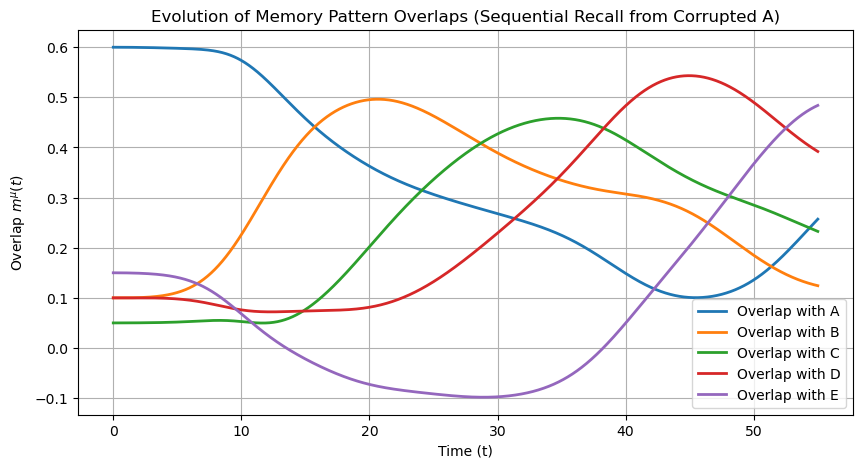

In [7]:
trial_data = run_trial(DEFAULTS, mode="ode")

plt.figure(figsize=(10, 5))
for mu, name in enumerate(MEMORY_NAMES):
    plt.plot(
        trial_data['time'],
        trial_data['overlap_history'][:, mu],
        linewidth=2.0,
        label=f'Overlap with {name}'
    )

plt.title("Evolution of Memory Pattern Overlaps (Sequential Recall from Corrupted A)")
plt.xlabel("Time (t)")
plt.ylabel("Overlap $m^\\mu(t)$")
plt.legend()
plt.grid(True)

plt.show()

## 2. Multiple Sequences with a Shared First Pattern

We now store $K=3$ short sequences that share only their first pattern and diverge immediately afterward:

$$
\mathcal S^{(1)}: A\to B\to C,
\qquad
\mathcal S^{(2)}: A\to D\to E,
\qquad
\mathcal S^{(3)}: A\to F\to G.
$$

There are 7 distinct stored patterns in total ($A,\dots,G$); $A$ is literally the same pattern vector in all three sequences, while $B,C,D,E,F,G$ are each unique to one sequence. The dynamics are the direct multi-sequence extension from the top of the notebook,

$$
\dot{\theta}_i
=
-\sin\theta_i
\sum_{a=1}^{K}
\sum_{\mu=1}^{P_a}
\xi_i^{a,\mu+1}
\left(
\frac{1}{N-1}
\sum_{j\neq i}
\xi_j^{a,\mu}
\cos\theta_j
\right)^d,
\qquad
\xi^{a,P_a+1}\equiv\xi^{a,1},
$$

implemented as a flat list of $(from,to)$ transition edges (3 edges per sequence, 9 total). Because all three sequences start at $A$, the term $S_A^d$ (the overlap with $A$, raised to the $d$-th power) is reused by three outgoing edges $A\to B$, $A\to D$, $A\to F$ simultaneously — so a corrupted cue of $A$ alone drives an immediate three-way tie right after the first step, with no shared intermediate patterns left to reinforce any one branch.

In [8]:
ALL_PATTERN_NAMES = ["A", "B", "C", "D", "E", "F", "G"]

SEQUENCE_LETTERS = {
    "ABC": ["A", "B", "C"],
    "ADE": ["A", "D", "E"],
    "AFG": ["A", "F", "G"],
}


def make_multi_memories(N=40, seed=DEFAULTS["seed"]):
    """Generate one random binary phase pattern per unique letter (A..G). The shared
    letter (A) is the same pattern vector wherever it appears, so the interference
    between sequences is entirely a consequence of the shared first pattern, not of
    accidentally distinct copies."""
    rng = np.random.default_rng(seed)
    phases = rng.choice([0.0, np.pi], size=(len(ALL_PATTERN_NAMES), N))
    xi = np.cos(phases)

    name_to_idx = {name: idx for idx, name in enumerate(ALL_PATTERN_NAMES)}
    sequences = {
        seq_name: np.array([name_to_idx[letter] for letter in letters], dtype=np.int64)
        for seq_name, letters in SEQUENCE_LETTERS.items()
    }
    return phases, xi, sequences


def build_transition_edges(sequences):
    """Flatten every sequence's periodic mu -> mu+1 transitions into one (from, to) edge list.

    A transition shared by multiple sequences (e.g. A -> B) is appended once per sequence,
    so summing over edges reproduces sum_a sum_mu (...) from the update rule exactly.
    """
    edges_from, edges_to = [], []
    for seq_idx in sequences.values():
        P = len(seq_idx)
        for mu in range(P):
            edges_from.append(seq_idx[mu])
            edges_to.append(seq_idx[(mu + 1) % P])
    return np.array(edges_from, dtype=np.int64), np.array(edges_to, dtype=np.int64)


### Multi-sequence ODE / SDE dynamics

The per-pattern leave-one-out overlap $S_p$ only depends on the pattern index $p$, not on
which sequence it belongs to, so it is computed once per pattern per timestep (7 values)
and then reused by every edge that starts from that pattern — this is what makes the
tripled reuse of $S_A$ across the three outgoing edges ($A\to B$, $A\to D$, $A\to F$)
explicit rather than accidental.

In [9]:
def simulate_multi_ode_euler(omega, phases, xi, edges_from, edges_to, d=DEFAULTS["d"], dt=DEFAULTS["dt"],
                              T=DEFAULTS["T"], cue_idx=0, corruption_rate=DEFAULTS["corruption_rate"],
                              seed=DEFAULTS["seed"]):
    """
    Deterministic Forward Euler simulation of the multi-sequence high-order Kuramoto network.
    theta is initialized at a corrupted copy of the pattern `cue_idx`.
    """
    num_steps = int(T / dt)
    theta_init = corrupt_pattern(phases[cue_idx], corruption_rate=corruption_rate, seed=seed)
    return _simulate_multi_ode_euler_impl(theta_init, omega, xi, edges_from, edges_to, d, dt, num_steps)


@njit
def _simulate_multi_ode_euler_impl(theta_init, omega, xi, edges_from, edges_to, d, dt, num_steps):
    N = theta_init.shape[0]
    num_patterns = xi.shape[0]
    num_edges = edges_from.shape[0]

    history = np.empty((num_steps + 1, N), dtype=np.float64)
    theta = theta_init.copy()
    history[0] = theta

    cos_theta = np.empty(N, dtype=np.float64)
    sin_theta = np.empty(N, dtype=np.float64)
    S = np.empty(num_patterns, dtype=np.float64)

    for step in range(num_steps):
        for i in range(N):
            cos_theta[i] = np.cos(theta[i])
            sin_theta[i] = np.sin(theta[i])

        # Overlap with every stored pattern, computed once and reused across sequences
        for p in range(num_patterns):
            temp_sum = 0.0
            for j in range(N):
                temp_sum += xi[p, j] * cos_theta[j]
            S[p] = temp_sum

        V = np.zeros(N, dtype=np.float64)
        for e in range(num_edges):
            frm = edges_from[e]
            to = edges_to[e]
            for i in range(N):
                inner_sum = S[frm] - xi[frm, i] * cos_theta[i]
                h = (inner_sum / (N - 1)) ** d
                V[i] += xi[to, i] * h

        for i in range(N):
            dtheta_i = omega[i] - sin_theta[i] * V[i]
            theta[i] = theta[i] + dt * dtheta_i

        history[step + 1] = theta.copy()

    return history

In [10]:
def simulate_multi_sde_maruyama(omega, phases, xi, edges_from, edges_to, d=DEFAULTS["d"], dt=DEFAULTS["dt"],
                                 T=DEFAULTS["T"], phase_noise=DEFAULTS["phase_noise"], cue_idx=0,
                                 corruption_rate=DEFAULTS["corruption_rate"], seed=DEFAULTS["seed"]):
    """
    Stochastic Euler-Maruyama simulation of the multi-sequence high-order Kuramoto network.
    """
    num_steps = int(T / dt)
    theta_init = corrupt_pattern(phases[cue_idx], corruption_rate=corruption_rate, seed=seed)
    return _simulate_multi_sde_maruyama_impl(theta_init, omega, xi, edges_from, edges_to, d, dt, num_steps, phase_noise)


@njit
def _simulate_multi_sde_maruyama_impl(theta_init, omega, xi, edges_from, edges_to, d, dt, num_steps, phase_noise):
    N = theta_init.shape[0]
    num_patterns = xi.shape[0]
    num_edges = edges_from.shape[0]

    history = np.empty((num_steps + 1, N), dtype=np.float64)
    theta = theta_init.copy()
    history[0] = theta

    cos_theta = np.empty(N, dtype=np.float64)
    sin_theta = np.empty(N, dtype=np.float64)
    S = np.empty(num_patterns, dtype=np.float64)

    noise_scale = phase_noise * np.sqrt(dt)

    for step in range(num_steps):
        for i in range(N):
            cos_theta[i] = np.cos(theta[i])
            sin_theta[i] = np.sin(theta[i])

        for p in range(num_patterns):
            temp_sum = 0.0
            for j in range(N):
                temp_sum += xi[p, j] * cos_theta[j]
            S[p] = temp_sum

        V = np.zeros(N, dtype=np.float64)
        for e in range(num_edges):
            frm = edges_from[e]
            to = edges_to[e]
            for i in range(N):
                inner_sum = S[frm] - xi[frm, i] * cos_theta[i]
                h = (inner_sum / (N - 1)) ** d
                V[i] += xi[to, i] * h

        for i in range(N):
            dtheta_i = omega[i] - sin_theta[i] * V[i]
            random_shock = np.random.randn()
            theta[i] = theta[i] + (dt * dtheta_i) + (noise_scale * random_shock)

        history[step + 1] = theta.copy()

    return history

In [11]:
def sequence_overlap(theta, xi, sequence_idx):
    """m^{a,mu}(t) = (1/N) sum_i xi_i^{a,mu} cos(theta_i(t)).

    The overlap between the dynamically evolving (corrupted-then-integrated) state theta(t)
    and every pattern belonging to one specific stored sequence `a`, indexed by
    `sequence_idx` (the pattern rows of xi that make up that sequence).
    """
    xi_a = xi[sequence_idx]
    return xi_a @ np.cos(theta) / xi_a.shape[1]


def run_multi_trial(config, cue_name, sequences, phases, xi, mode="ode"):
    """
    Run one multi-sequence trial: corrupt a copy of pattern `cue_name`, evolve the combined
    dynamics, and compute the sequence-specific overlaps m^{a,mu}(t) against all three
    stored sequences (not just the one the cue nominally belongs to).
    """
    N = config['N']
    dt = config['dt']
    T = config['T']
    frequency_std = config['frequency_std']
    phase_noise = config['phase_noise']
    corruption_rate = config['corruption_rate']
    seed = config['seed']
    d = config['d']

    num_steps = int(T / dt)
    time_vector = np.linspace(0, T, num_steps + 1)

    edges_from, edges_to = build_transition_edges(sequences)

    rng = np.random.default_rng(seed)
    omega = rng.normal(0.0, frequency_std, N)

    cue_idx = ALL_PATTERN_NAMES.index(cue_name)

    if mode == 'ode':
        theta_history = simulate_multi_ode_euler(
            omega=omega, phases=phases, xi=xi, edges_from=edges_from, edges_to=edges_to,
            d=d, dt=dt, T=T, cue_idx=cue_idx, corruption_rate=corruption_rate, seed=seed,
        )
    elif mode == 'sde':
        theta_history = simulate_multi_sde_maruyama(
            omega=omega, phases=phases, xi=xi, edges_from=edges_from, edges_to=edges_to,
            d=d, dt=dt, T=T, phase_noise=phase_noise, cue_idx=cue_idx,
            corruption_rate=corruption_rate, seed=seed,
        )
    else:
        raise ValueError("Mode must be either 'ode' or 'sde'")

    sequence_overlaps = {
        seq_name: np.array([sequence_overlap(theta, xi, idx) for theta in theta_history])
        for seq_name, idx in sequences.items()
    }

    return {
        "time": time_vector,
        "theta_history": theta_history,
        "cue": cue_name,
        "sequence_overlaps": sequence_overlaps,
    }


def plot_multi_trial(result):
    """Plot m^{a,mu}(t) for each stored sequence in its own panel."""
    seq_names = list(SEQUENCE_LETTERS.keys())
    fig, axes = plt.subplots(len(seq_names), 1, figsize=(10, 3.6 * len(seq_names)), sharex=True)

    for ax, seq_name in zip(axes, seq_names):
        q = result["sequence_overlaps"][seq_name]
        for mu, letter in enumerate(SEQUENCE_LETTERS[seq_name]):
            ax.plot(result["time"], q[:, mu], linewidth=2.0, label=f"Overlap with {letter}")
        ax.set_ylabel(r"$m^{a,\mu}(t)$")
        ax.set_title(f"Sequence {seq_name}")
        ax.legend(ncol=5)
        ax.grid(True)

    axes[-1].set_xlabel("Time (t)")
    fig.suptitle(f"Multi-sequence recall cued from corrupted '{result['cue']}'")
    fig.tight_layout()
    plt.show()

### 2.1 Cueing from the shared prefix

All three sequences start with $A$, so a corrupted copy of $A$ carries no information
about which sequence should be recalled. 

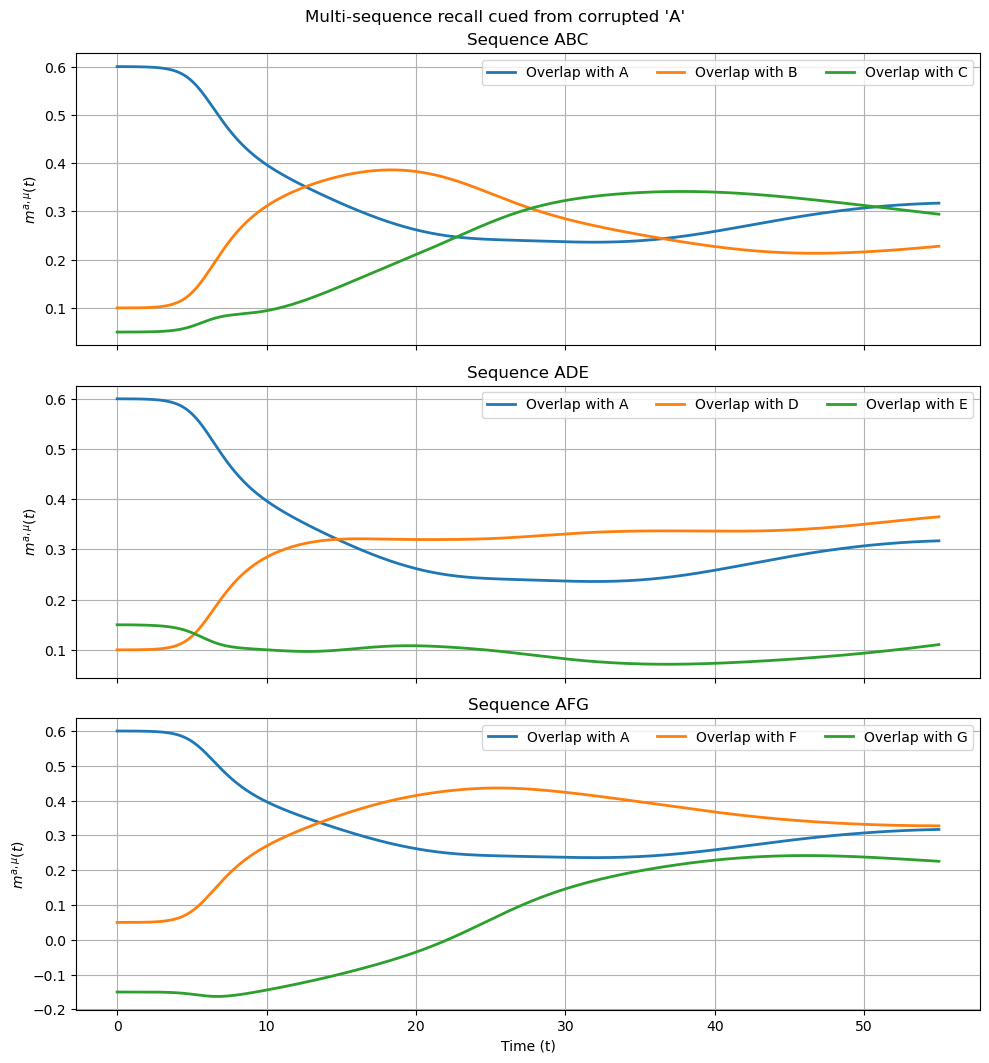

In [12]:
phases_multi, xi_multi, sequences_multi = make_multi_memories(N=DEFAULTS["N"], seed=DEFAULTS["seed"])

trial_cue_A = run_multi_trial(
    DEFAULTS, cue_name="A", sequences=sequences_multi,
    phases=phases_multi, xi=xi_multi, mode="ode",
)
plot_multi_trial(trial_cue_A)